In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
import pkg_resources

needed = [
    "numpy", "pandas", "scikit-learn",
    "xgboost", "lightgbm", "imbalanced-learn",
    "matplotlib"
]

installed = {pkg.key: pkg.version for pkg in pkg_resources.working_set}

for name in needed:
    if name in installed:
        print(f"{name}=={installed[name]}")
    else:
        print(f"{name} (Not installed)")


numpy==2.2.6
pandas==2.2.3
scikit-learn==1.7.1
xgboost==2.1.4
lightgbm==4.5.0
imbalanced-learn==0.14.0
matplotlib==3.10.5


C:\Users\Admin\AppData\Local\Temp\ipykernel_10876\3674952356.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [8]:

import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, ConfusionMatrixDisplay

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE
from xgboost import XGBClassifier

# ===== 경로/설정 =====
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_feature_engineered_plus.csv"
FIXED_THRESHOLD = 0.84  # 필요 시 조정
OUTDIR = Path(INPUT_CSV).with_name("학습결과_BSMOTE")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ===== 데이터 =====
if not os.path.exists(INPUT_CSV):
    raise FileNotFoundError(f"입력 CSV가 없습니다: {INPUT_CSV}")
df = pd.read_csv(INPUT_CSV)

if "업무평가" not in df.columns:
    raise KeyError("'업무평가' 열이 없습니다.")

# 타깃 매핑: 보통/0 -> 0, 좋다/좋음/1 -> 1
y = (df["업무평가"].astype(str).str.strip().str.lower()
     .map({"보통":0, "0":0, "좋다":1, "좋음":1, "1":1}).astype(int))
X = df.drop(columns=["업무평가"])

# 범주/수치 분리
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# 전처리
numeric_tf = SimpleImputer(strategy="median")
categorical_tf = ImbPipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
preprocess = ColumnTransformer([
    ("num", numeric_tf, num_cols),
    ("cat", categorical_tf, cat_cols),
])

# 학습/검증 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 모델
xgb = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.07,
    subsample=0.9, colsample_bytree=0.9,
    objective="binary:logistic", eval_metric="logloss",
    random_state=42, n_jobs=-1, tree_method="hist"
)

# 파이프라인 (Borderline-SMOTE 포함)
model = ImbPipeline([
    ("preprocess", preprocess),
    ("bsmote", BorderlineSMOTE(random_state=42)),
    ("clf", xgb),
])

# 학습
model.fit(X_train, y_train)

# 평가 (고정 임계값)
proba = model.predict_proba(X_test)[:, 1]
pred  = (proba >= FIXED_THRESHOLD).astype(int)

acc   = accuracy_score(y_test, pred)
prec0 = precision_score(y_test, pred, pos_label=0, zero_division=0)
prec1 = precision_score(y_test, pred, pos_label=1, zero_division=0)

print("[Result]")
print(f"Used threshold : {FIXED_THRESHOLD:.2f}")
print(f"Accuracy       : {acc:.4f}")
print(f"Precision(0)   : {prec0:.4f}")
print(f"Precision(1)   : {prec1:.4f}")

# 혼동행렬 저장
cm = confusion_matrix(y_test, pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(values_format="d", cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix @ th={FIXED_THRESHOLD:.2f}")
plt.tight_layout()
plt.savefig(OUTDIR / "confusion_matrix.png", dpi=150)
plt.close()

print(f"\n[저장 완료] {OUTDIR}/confusion_matrix.png")


[Result]
Used threshold : 0.84
Accuracy       : 0.8537
Precision(0)   : 0.8527
Precision(1)   : 1.0000

[저장 완료] C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\학습결과_BSMOTE/confusion_matrix.png


In [9]:
import joblib
from pathlib import Path

OUTDIR = Path(r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\학습결과_BSMOTE")
OUTDIR.mkdir(parents=True, exist_ok=True)

PKL_PATH = OUTDIR / "final_model.pkl"

# model 객체 + threshold + meta 한 번에 묶어서 저장
package = {
    "model": model,             # 학습된 파이프라인
    "threshold": 0.84,          # FIXED_THRESHOLD
    "cat_cols": cat_cols,       # 범주형 칼럼
    "num_cols": num_cols        # 수치형 칼럼
}
joblib.dump(package, PKL_PATH)

print(f"[저장 완료] {PKL_PATH}")


[저장 완료] C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\학습결과_BSMOTE\final_model.pkl


In [10]:
import joblib
import pandas as pd
import numpy as np

PKL_PATH = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\학습결과_BSMOTE\final_model.pkl"
package   = joblib.load(PKL_PATH)
model     = package["model"]
th        = package["threshold"]
num_cols  = list(package["num_cols"])
cat_cols  = list(package["cat_cols"])


BASE_INPUT_COLS = [
    "출장", "전년도교육출장횟수", "이직회수", "참여프로젝트", "월급_KRW", "경력",
    "현회사근속년수", "근속연차", "주변평가", "부서", "전공", "직급관리자여부"
]

# 전공 허용 목록 (CSV 기준)
MAJOR_ALLOWED = ["공학계열","자연과학계열","사회과학계열","상경계열","인문학","기타"]

def safe_div_series(a: pd.Series, b: pd.Series) -> pd.Series:
    a_ = pd.to_numeric(a, errors="coerce")
    b_ = pd.to_numeric(b, errors="coerce").replace(0, np.nan)
    return a_ / b_

def _input_with_guide(col: str):
    """원본 컬럼 입력 규칙"""
    # 출장: 실제 횟수(정수)
    if col == "출장":
        while True:
            val = input(f"{col} 값 입력 (정수, 실제 출장 횟수): ").strip()
            try:
                iv = int(val)
                if iv < 0:
                    print(" 음수는 허용되지 않습니다.")
                    continue
                return iv
            except:
                print(" 정수로 입력하세요.")

    # 전년도교육출장횟수 (정수)
    if col == "전년도교육출장횟수":
        while True:
            val = input(f"{col} 값 입력 (정수, 실제 횟수): ").strip()
            try:
                iv = int(val)
                if iv < 0:
                    print(" 음수는 허용되지 않습니다.")
                    continue
                return iv
            except:
                print(" 정수로 입력하세요.")

    # 주변평가 (1~4)
    if col == "주변평가":
        while True:
            val = input(f"{col} 값 입력 (1=매우 낮음, 2=보통, 3=좋음, 4=매우 좋음): ").strip()
            if val in {"1","2","3","4"}:
                return int(val)
            print(" 1~4 사이 정수만 허용됩니다.")

    # 전공 (고정 셋)
    if col == "전공":
        while True:
            val = input(f"{col} 값 입력 (선택지: {', '.join(MAJOR_ALLOWED)}): ").strip()
            if val in MAJOR_ALLOWED:
                return val
            print("목록 중 하나를 정확히 입력하세요.")

    # 부서 (0=R&D, 1=영업, 2=사무직)
    if col == "부서":
        while True:
            val = input(f"{col} 값 입력 (0=R&D, 1=영업, 2=사무직): ").strip()
            if val in {"0","1","2"}:
                return int(val)
            print(" 0/1/2 중에서만 입력하세요.")

    # 직급관리자여부 (0/1)
    if col == "직급관리자여부":
        while True:
            val = input(f"{col} 값 입력 (0=일반직, 1=관리직 이상): ").strip()
            if val in {"0","1"}:
                return int(val)
            print(" 0 또는 1만 허용됩니다.")

    # 일반 수치형
    if col in {"월급_KRW","경력","근속연차","이직회수","참여프로젝트","현회사근속년수"}:
        raw = input(f"{col} 값 입력 (숫자, 미입력 시 Enter): ").strip()
        if raw == "":
            return np.nan
        try:
            return float(raw)
        except:
            print(" 숫자로 변환할 수 없어 NaN으로 처리됩니다.")
            return np.nan

    # 예외(보수적)
    raw = input(f"{col} 값 입력: ").strip()
    try:
        return float(raw)
    except:
        return raw if raw != "" else None

def _compute_known_derived(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    expected = set(num_cols + cat_cols)

    # ── 근속/경력 관련 ───────────────────────────────────────────
    if "총근속" in expected and "근속연차" in out.columns:
        out["총근속"] = pd.to_numeric(out["근속연차"], errors="coerce")

    if "평균근속기간" in expected and {"경력","이직회수"}.issubset(out.columns):
        num_ = pd.to_numeric(out["경력"], errors="coerce")
        den_ = pd.to_numeric(out["이직회수"], errors="coerce") + 1
        den_.replace(0, np.nan, inplace=True)
        out["평균근속기간"] = num_ / den_

    if "현근속_총경력비" in expected and {"현회사근속년수","경력"}.issubset(out.columns):
        out["현근속_총경력비"] = safe_div_series(out["현회사근속년수"], out["경력"])

    if "근속_경력비" in expected and {"근속연차","경력"}.issubset(out.columns):
        out["근속_경력비"] = safe_div_series(out["근속연차"], out["경력"])

    if "경력성장률" in expected and {"경력","근속연차"}.issubset(out.columns):
        out["경력성장률"] = safe_div_series(out["경력"], out["근속연차"])

    if "이직빈도" in expected and {"이직회수","경력"}.issubset(out.columns):
        out["이직빈도"] = safe_div_series(out["이직회수"], out["경력"])

    # ── 프로젝트/출장/교육 관련 ────────────────────────────────
    if "학습몰입도" in expected and {"참여프로젝트","전년도교육출장횟수"}.issubset(out.columns):
        out["학습몰입도"] = (
            pd.to_numeric(out["참여프로젝트"], errors="coerce") *
            pd.to_numeric(out["전년도교육출장횟수"], errors="coerce")
        )

    # 출장 파생(실제 출장 횟수 기반)
    if "출장_경력비" in expected and {"출장","경력"}.issubset(out.columns):
        out["출장_경력비"] = safe_div_series(out["출장"], out["경력"])

    if "출장_근속연차비" in expected and {"출장","근속연차"}.issubset(out.columns):
        out["출장_근속연차비"] = safe_div_series(out["출장"], out["근속연차"])

    # 프로젝트 비율
    if "프로젝트_경력비" in expected and {"참여프로젝트","경력"}.issubset(out.columns):
        out["프로젝트_경력비"] = safe_div_series(out["참여프로젝트"], out["경력"])

    if "프로젝트_근속연차비" in expected and {"참여프로젝트","근속연차"}.issubset(out.columns):
        out["프로젝트_근속연차비"] = safe_div_series(out["참여프로젝트"], out["근속연차"])

    # 교육출장 비율
    if "교육출장_경력비" in expected and {"전년도교육출장횟수","경력"}.issubset(out.columns):
        out["교육출장_경력비"] = safe_div_series(out["전년도교육출장횟수"], out["경력"])
        # ── 학습몰입도 (참여프로젝트 × 전년도교육출장횟수)
    if "학습몰입도" in expected and {"참여프로젝트","전년도교육출장횟수"}.issubset(out.columns):
        out["학습몰입도"] = (
            pd.to_numeric(out["참여프로젝트"], errors="coerce") *
            pd.to_numeric(out["전년도교육출장횟수"], errors="coerce")
        )

    # ── 학습몰입도_교육출장 (학습몰입도 × 전년도교육출장횟수)
    if "학습몰입도_교육출장" in expected and {"학습몰입도","전년도교육출장횟수"}.issubset(out.columns):
        out["학습몰입도_교육출장"] = (
            pd.to_numeric(out["학습몰입도"], errors="coerce") *
            pd.to_numeric(out["전년도교육출장횟수"], errors="coerce")
        )


    # ── 월급_KRW 기반 파생 ─────────────────────────────────────
    if "월급_경력비" in expected and {"월급_KRW","경력"}.issubset(out.columns):
        out["월급_경력비"] = safe_div_series(out["월급_KRW"], out["경력"])

    if "월급_프로젝트비" in expected and {"월급_KRW","참여프로젝트"}.issubset(out.columns):
        out["월급_프로젝트비"] = safe_div_series(out["월급_KRW"], out["참여프로젝트"])

    if "월급_근속연차비" in expected and {"월급_KRW","근속연차"}.issubset(out.columns):
        out["월급_근속연차비"] = safe_div_series(out["월급_KRW"], out["근속연차"])

    if "월급_출장비" in expected:
        if {"월급_KRW","전년도교육출장횟수"}.issubset(out.columns):
            out["월급_출장비"] = safe_div_series(out["월급_KRW"], out["전년도교육출장횟수"])
        elif {"월급_KRW","출장"}.issubset(out.columns):
            out["월급_출장비"] = safe_div_series(out["월급_KRW"], out["출장"])

    # ── 주변평가 기반 ─────────────────────────────────────
    if "주변평가_근속연차" in expected and {"주변평가","근속연차"}.issubset(out.columns):
        out["주변평가_근속연차"] = (
            pd.to_numeric(out["주변평가"], errors="coerce") *
            pd.to_numeric(out["근속연차"], errors="coerce")
        )


    return out

def predict_input():
    print("\n===== 입력 안내 =====")
    print("  * 출장: 실제 횟수(정수)")
    print("  * 전년도교육출장횟수: 실제 횟수(정수)")
    print("  * 주변평가: 1~4 정수 (1=매우 낮음, 2=보통, 3=좋음, 4=매우 좋음)")
    print("  * 전공: 공학계열, 자연과학계열, 사회과학계열, 상경계열, 인문학, 기타")
    print("  * 부서: 0=R&D, 1=영업, 2=사무직")
    print("  * 직급관리자여부: 0=일반직, 1=관리직 이상")
    print("  * 월급_KRW: 실제 월급(원화 환산)\n")

    # 1) 원본 입력 받기
    sample = {col: _input_with_guide(col) for col in BASE_INPUT_COLS}
    df_sample = pd.DataFrame([sample])

    # 2) 파생 자동 계산
    df_full = _compute_known_derived(df_sample)

    # 3) 모델 기대 컬럼 채우기/정렬
    expected_cols = num_cols + cat_cols
    missing = []
    for c in expected_cols:
        if c not in df_full.columns:
            df_full[c] = np.nan
            missing.append(c)
    df_full = df_full[expected_cols]

    if missing:
        print(" 아래 컬럼은 원본에서 직접 입력받지 않거나 규칙에 맞는 파생 계산식을 찾지 못해 NaN으로 처리되었습니다:")
        print("   - " + ", ".join(missing))

    # 4) 예측
    prob = model.predict_proba(df_full)[:, 1][0]
    pred = int(prob >= th)
    label = {0: "보통", 1: "좋다"}[pred]

    print("\n[예측 결과]")
    print(f"확률(좋다 class=1): {prob:.4f}")
    print(f"임계값             : {th:.2f}")
    print(f"최종 예측          : {pred} ({label})")

if __name__ == "__main__":
    predict_input()



===== 입력 안내 =====
  * 출장: 실제 횟수(정수)
  * 전년도교육출장횟수: 실제 횟수(정수)
  * 주변평가: 1~4 정수 (1=매우 낮음, 2=보통, 3=좋음, 4=매우 좋음)
  * 전공: 공학계열, 자연과학계열, 사회과학계열, 상경계열, 인문학, 기타
  * 부서: 0=R&D, 1=영업, 2=사무직
  * 직급관리자여부: 0=일반직, 1=관리직 이상
  * 월급_KRW: 실제 월급(원화 환산)

출장 값 입력 (정수, 실제 출장 횟수): 
 정수로 입력하세요.


KeyboardInterrupt: Interrupted by user

In [11]:
import joblib


joblib.dump(FINAL_MODEL, "xg+BS_model_precision1.joblib")
print("저장 완료: xg+BS_precision1.joblib")


NameError: name 'FINAL_MODEL' is not defined

In [3]:
# -*- coding: utf-8 -*-
"""
세 모델 일괄 비교 (빠른 실행용)
- 대상: RandomForest, XGBoost, LightGBM
- 핵심 지표: Accuracy (정확도 중심), 보조로 Precision/Recall/F1(positive=1, '좋다')
- 옵션: BorderlineSMOTE 적용 여부, 분류 임계값(THRESHOLD) 고정
"""

import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# ==== [옵션] =========================================================
CSV_PATH   = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_feature_engineered_plus.csv"  # 로컬 경로로 변경 가능
TARGET_COL = "업무평가"  # 데이터에 '업무평가2'가 없다고 하셨으니 기본값 유지
RANDOM_SEED = 42

USE_SMOTE  = False  # 샘플링은 "샘플 모델 우선 점검 후" 적용 원칙 → 기본 False
THRESHOLD  = None   # 예: 0.84 로 고정하면 precision↑, recall↓ 가능성 / None이면 기본 0.5
TEST_SIZE  = 0.2
# ====================================================================

# ---- 모델 로더 (설치 여부에 따라 graceful fallback)
from sklearn.ensemble import RandomForestClassifier
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

# ---- SMOTE 옵션
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import BorderlineSMOTE
    HAS_IMB = True
except Exception:
    HAS_IMB = False
    USE_SMOTE = False  # 사용 불가 시 자동 비활성화

# ==== 1) 데이터 로드 & 타깃 인코딩 ===================================
df = pd.read_csv(CSV_PATH)

if TARGET_COL not in df.columns:
    raise KeyError(f"'{TARGET_COL}' 컬럼을 찾을 수 없습니다. 실제 컬럼명을 확인하세요.")

# 타깃을 0/1로 통일 (문자열 → 정수). '좋다','좋음'을 1로 처리
y_raw = df[TARGET_COL].copy()
if y_raw.dtype == 'object':
    y = y_raw.map({'보통':0, '좋다':1, '좋음':1})
else:
    y = y_raw.copy()

if y.isna().any():
    raise ValueError("타깃 인코딩 결과 NaN 발생. 타깃 라벨 값을 확인하세요.")

X = df.drop(columns=[TARGET_COL])

# 범주/수치 분리
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# ==== 2) 전처리 파이프라인 ==========================================
cat_tf = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("enc",    OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
num_tf = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median"))
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_tf, num_cols),
        ("cat", cat_tf, cat_cols)
    ],
    remainder="drop"
)

# ==== 3) 후보 모델 정의 =============================================
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500, max_depth=None, n_jobs=-1, random_state=RANDOM_SEED
        # 필요 시 class_weight="balanced" 고려 (정확도 중심이면 기본값부터 점검 권장)
    )
}

if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        objective="binary:logistic", eval_metric="logloss",
        n_jobs=-1, random_state=RANDOM_SEED
        # 불균형 대응: scale_pos_weight는 후속 실험에서 조절
    )

if HAS_LGBM:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=800, max_depth=-1, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_SEED, n_jobs=-1
        # class_weight="balanced"는 후속 실험에서 조절
    )

# ==== 4) 데이터 분할 =================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
)

# ==== 5) 학습 & 평가 유틸 ============================================
def build_pipe(model):
    """전처리(+선택적으로 SMOTE) + 분류기"""
    if USE_SMOTE and HAS_IMB:
        return ImbPipeline(steps=[
            ("prep", preprocess),
            ("smote", BorderlineSMOTE(random_state=RANDOM_SEED)),
            ("clf", model)
        ])
    else:
        return Pipeline(steps=[
            ("prep", preprocess),
            ("clf", model)
        ])

def predict_with_threshold(clf, X_eval, threshold=None):
    """threshold를 적용한 예측(없으면 기본 predict)"""
    if threshold is None:
        return clf.predict(X_eval)
    # 확률 기반 임계값 적용
    proba = clf.predict_proba(X_eval)[:, 1]
    return (proba >= threshold).astype(int)

def evaluate(name, clf, X_tr, y_tr, X_te, y_te, threshold=None, verbose=True):
    y_pred = predict_with_threshold(clf, X_te, threshold)
    acc = accuracy_score(y_te, y_pred)
    p1  = precision_score(y_te, y_pred, pos_label=1, zero_division=0)
    r1  = recall_score(y_te, y_pred, pos_label=1, zero_division=0)
    f1  = f1_score(y_te, y_pred, pos_label=1, zero_division=0)
    cm  = confusion_matrix(y_te, y_pred)

    if verbose:
        print(f"\n[{name}] threshold={threshold if threshold is not None else 0.5}")
        print(f"  Accuracy      : {acc:.4f}")
        print(f"  Precision(1)  : {p1:.4f}")
        print(f"  Recall(1)     : {r1:.4f}")
        print(f"  F1(1)         : {f1:.4f}")
        print(f"  Confusion Matrix:\n{cm}")

    return {
        "model": name,
        "threshold": threshold if threshold is not None else 0.5,
        "accuracy": acc,
        "precision_1": p1,
        "recall_1": r1,
        "f1_1": f1
    }

# ==== 6) 실행 =======================================================
results = []
fitted = {}

for name, mdl in models.items():
    pipe = build_pipe(mdl)
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    # 기본(0.5) 평가
    results.append(evaluate(name, pipe, X_train, y_train, X_test, y_test,
                            threshold=None, verbose=True))

    # 임계값 고정 평가(선택)
    if THRESHOLD is not None:
        results.append(evaluate(name + " (th)", pipe, X_train, y_train, X_test, y_test,
                                threshold=THRESHOLD, verbose=True))

# ==== 7) 결과 비교표 ================================================
res_df = pd.DataFrame(results).sort_values(by=["accuracy","f1_1"], ascending=False)
print("\n=== 종합 비교표 (정확도 우선 정렬) ===")
print(res_df.to_string(index=False))

# 필요시: 상위 모델의 Feature Importance(트리계열) 확인
def get_feature_names(preprocess, num_cols, cat_cols):
    """전처리 후 특성 이름 추적(간단 버전: 수치+범주 원본 이름 그대로)"""
    # OrdinalEncoder는 카테고리 확장 없이 1개 컬럼→1개 컬럼 유지
    return num_cols + cat_cols

top_model_name = res_df.iloc[0]["model"].replace(" (th)","")
top_pipe = fitted[top_model_name]
clf = top_pipe.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    feat_names = get_feature_names(preprocess, num_cols, cat_cols)
    imp = pd.DataFrame({"feature": feat_names, "importance": clf.feature_importances_}) \
            .sort_values("importance", ascending=False)
    print("\n[Top 모델 Feature Importance 상위 10]")
    print(imp.head(10).to_string(index=False))



[RandomForest] threshold=0.5
  Accuracy      : 0.8435
  Precision(1)  : 0.3333
  Recall(1)     : 0.0222
  F1(1)         : 0.0417
  Confusion Matrix:
[[247   2]
 [ 44   1]]

[XGBoost] threshold=0.5
  Accuracy      : 0.8231
  Precision(1)  : 0.1818
  Recall(1)     : 0.0444
  F1(1)         : 0.0714
  Confusion Matrix:
[[240   9]
 [ 43   2]]
[LightGBM] [Info] Number of positive: 181, number of negative: 995
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000649 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2073
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.153912 -> initscore=-1.704246
[LightGBM] [Info] Start training from score -1.704246

[LightGBM] threshold=0.5
  Accuracy      : 0.8129
  Precision(1)  : 0.1429
  Recall(1)     : 0.0444
  F1(

In [9]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,  # ← 추가
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE
from xgboost import XGBClassifier

# ===== 경로/설정 =====
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_feature_engineered_plus.csv"
FIXED_THRESHOLD = 0.84  # 필요 시 조정
OUTDIR = Path(INPUT_CSV).with_name("학습결과_BSMOTE")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ===== 데이터 =====
if not os.path.exists(INPUT_CSV):
    raise FileNotFoundError(f"입력 CSV가 없습니다: {INPUT_CSV}")
df = pd.read_csv(INPUT_CSV)

if "업무평가" not in df.columns:
    raise KeyError("'업무평가' 열이 없습니다.")

# 타깃 매핑: 보통/0 -> 0, 좋다/좋음/1 -> 1
y = (df["업무평가"].astype(str).str.strip().str.lower()
     .map({"보통":0, "0":0, "좋다":1, "좋음":1, "1":1}).astype(int))
X = df.drop(columns=["업무평가"])

# 범주/수치 분리
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# 전처리
numeric_tf = SimpleImputer(strategy="median")
categorical_tf = ImbPipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
preprocess = ColumnTransformer([
    ("num", numeric_tf, num_cols),
    ("cat", categorical_tf, cat_cols),
])

# 학습/검증 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 모델
xgb = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.07,
    subsample=0.9, colsample_bytree=0.9,
    objective="binary:logistic", eval_metric="logloss",
    random_state=42, n_jobs=-1, tree_method="hist"
)

# 파이프라인 (Borderline-SMOTE 포함)
model = ImbPipeline([
    ("preprocess", preprocess),
    ("bsmote", BorderlineSMOTE(random_state=42)),
    ("clf", xgb),
])

# ===== 학습 =====
model.fit(X_train, y_train)

# ===== (A) 기본 predict(=내부 임계값 0.5) 리포트: 이미지 형태 =====
pred_default = model.predict(X_test)
print("[Classification Report - Test]")
print(classification_report(y_test, pred_default, digits=4))

# 혼동행렬(기본 0.5) 저장
cm0 = confusion_matrix(y_test, pred_default, labels=[0, 1])
disp0 = ConfusionMatrixDisplay(confusion_matrix=cm0, display_labels=[0, 1])
disp0.plot(values_format="d", cmap="Blues", colorbar=False)
plt.title("Confusion Matrix @ predict (th=0.50)")
plt.tight_layout()
plt.savefig(OUTDIR / "confusion_matrix_default.png", dpi=150)
plt.close()

# ===== (B) 지정 임계값 리포트(예: 0.84) =====
proba = model.predict_proba(X_test)[:, 1]
pred_th = (proba >= FIXED_THRESHOLD).astype(int)

print(f"\n[Test] threshold={FIXED_THRESHOLD:.3f}")
print(classification_report(y_test, pred_th, digits=4))

# 혼동행렬(임계값) 저장
cm1 = confusion_matrix(y_test, pred_th, labels=[0, 1])
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=[0, 1])
disp1.plot(values_format="d", cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix @ th={FIXED_THRESHOLD:.2f}")
plt.tight_layout()
fname = f"confusion_matrix_th_{str(FIXED_THRESHOLD).replace('.', '_')}.png"
plt.savefig(OUTDIR / fname, dpi=150)
plt.close()

print("\n[저장 완료]")
print(f"- {OUTDIR / 'confusion_matrix_default.png'}")
print(f"- {OUTDIR / fname}")



[Classification Report - Test]
              precision    recall  f1-score   support

           0     0.8530    0.9558    0.9015       249
           1     0.2667    0.0889    0.1333        45

    accuracy                         0.8231       294
   macro avg     0.5599    0.5224    0.5174       294
weighted avg     0.7633    0.8231    0.7839       294


[Test] threshold=0.840
              precision    recall  f1-score   support

           0     0.8527    1.0000    0.9205       249
           1     1.0000    0.0444    0.0851        45

    accuracy                         0.8537       294
   macro avg     0.9264    0.5222    0.5028       294
weighted avg     0.8753    0.8537    0.7926       294


[저장 완료]
- C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\학습결과_BSMOTE\confusion_matrix_default.png
- C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\학습결과_BSMOTE\confusion_matrix_th_0_84.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지


[저장완료] 환율 반영 파일: C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_환율적용.csv
[저장완료] 라벨 인코딩 파일: C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_라벨인코딩.csv

[RandomForest] Test Accuracy: 0.8469
=== RandomForest Feature Importance (Top 20) ===
      feature  importance    cumsum
0          사번    0.112840  0.112840
1      월급_KRW    0.104510  0.217351
2          나이    0.080419  0.297770
3          거리    0.068918  0.366687
4          경력    0.066126  0.432814
5     현회사근속년수    0.064267  0.497081
6        이직회수    0.045410  0.542491
7   전년도교육출장횟수    0.040560  0.583050
8          직급    0.039926  0.622976
9          학력    0.038129  0.661105
10      직업만족도    0.034452  0.695557
11        만족도    0.034332  0.729889
12       주변평가    0.032441  0.762331
13         전공    0.031691  0.794022
14     참여프로젝트    0.030083  0.824105
15        워라밸    0.026986  0.851091
16     스톡옵션레벨    0.026028  0.877120
17         출장    0.024306  0.901425
18       결혼여부    0.023110  0.924536
19       근속연차    0.020178  0.944713


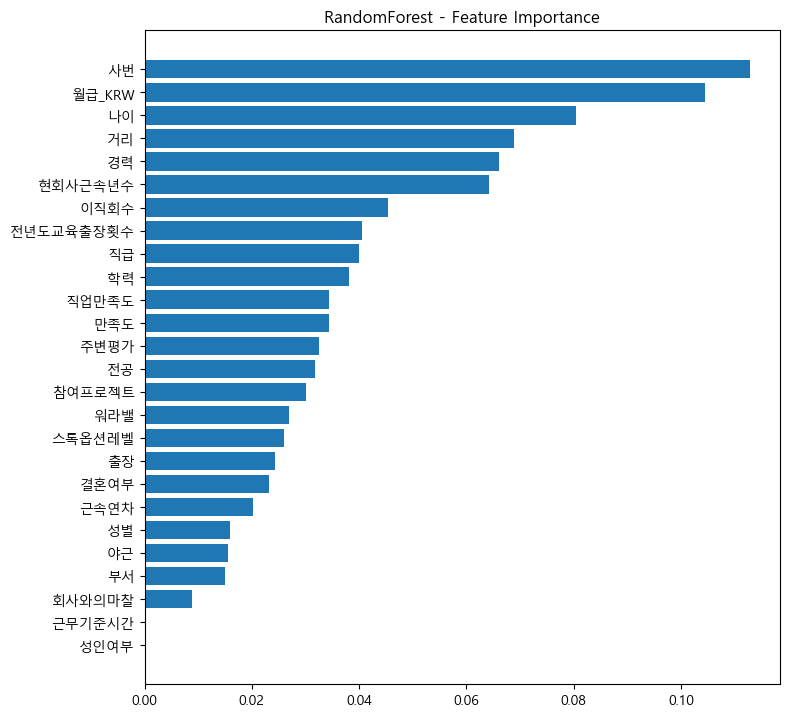


[XGBoost] Test Accuracy: 0.8333
=== XGBoost Feature Importance (Top 20) ===
    feature  importance    cumsum
0        야근    0.050358  0.050358
1        부서    0.046554  0.096913
2      주변평가    0.046211  0.143123
3       워라밸    0.046031  0.189154
4    월급_KRW    0.045754  0.234908
5    회사와의마찰    0.045540  0.280447
6        출장    0.045511  0.325959
7   현회사근속년수    0.044138  0.370096
8        나이    0.042990  0.413087
9      결혼여부    0.042880  0.455967
10       경력    0.042683  0.498650
11       학력    0.042363  0.541013
12       전공    0.041593  0.582605
13     이직회수    0.041025  0.623630
14       직급    0.040735  0.664366
15       거리    0.039862  0.704228
16   참여프로젝트    0.039669  0.743896
17   스톡옵션레벨    0.039120  0.783017
18       사번    0.039032  0.822049
19    직업만족도    0.037768  0.859818
[저장완료] XGBoost Feature Importance Plot → C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_xgb_feature_importance.png


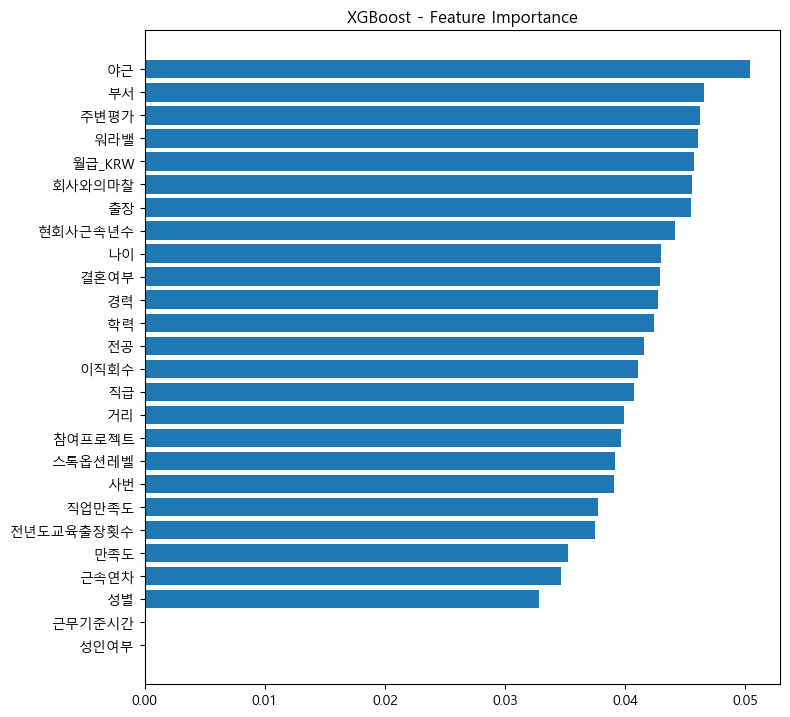

In [12]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ===== 옵션: XGBoost 사용 가능 여부 =====
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# ===== 경로 & 환율 =====
INPATH  = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가.csv"  # 원본
EXRATE_USD_KRW = 1380.0  # 최신 환율로 수정 가능

OUT_EXRATE = str(Path(INPATH).with_name(Path(INPATH).stem + "_환율적용.csv"))
OUT_LABEL  = str(Path(INPATH).with_name(Path(INPATH).stem + "_라벨인코딩.csv"))
OUTDIR     = Path(INPATH).parent  # 결과 저장 위치(같은 폴더)

# ===== 유틸 =====
def to_numeric_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace(",", ""), errors="coerce")

def normalize_currency(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip().str.upper()
    return s.replace({
        "달러":"USD", "US DOLLAR":"USD", "USD$":"USD", "$":"USD",
        "원":"KRW", "WON":"KRW", "KRW₩":"KRW", "￦":"KRW"
    })

def encode_trip_text(s: pd.Series) -> pd.Series:
    """출장: 0회→0, 1~29회→1, 30회 이상→2, 그 외/결측→-1"""
    x = s.astype(str).str.strip()
    x_norm = x.str.replace(" ", "", regex=False)

    map_dict = {
        "0회":0, "없음":0, "무":0, "no":0, "n":0, "0":0,
        "1~29회":1, "1-29회":1, "1~29":1, "1-29":1,
        "30회이상":2, "30+":2, "30이상":2, "30회↑":2
    }
    y = x_norm.map(map_dict)

    # 숫자만 온 경우(예: "12")
    is_num = x_norm.str.fullmatch(r"\d+")
    num_vals = pd.to_numeric(x_norm[is_num], errors="coerce")
    y.loc[is_num & (num_vals == 0)] = 0
    y.loc[is_num & (num_vals.between(1, 29))] = 1
    y.loc[is_num & (num_vals >= 30)] = 2

    return y.fillna(-1).astype(int)

# ===== 1) 환율 적용 & 저장 =====
df = pd.read_csv(INPATH)

# 월급 → KRW
if "월급" in df.columns:
    월급_num = to_numeric_series(df["월급"])
    if "통화" in df.columns:
        cur = normalize_currency(df["통화"])
        rate_map = {"USD": EXRATE_USD_KRW, "KRW": 1.0}
        cur_rate = cur.map(rate_map).fillna(EXRATE_USD_KRW)
        df["월급_KRW"] = 월급_num * cur_rate
    else:
        df["월급_KRW"] = 월급_num * EXRATE_USD_KRW
else:
    df["월급_KRW"] = np.nan

# 원본 월급/통화 제거
drop_cols = []
if "월급" in df.columns:   drop_cols.append("월급")
if "통화" in df.columns:   drop_cols.append("통화")
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)

# 환율 적용 저장
df.to_csv(OUT_EXRATE, index=False, encoding="utf-8-sig")
print(f"[저장완료] 환율 반영 파일: {OUT_EXRATE}")

# ===== 2) 부서/출장 값 교체 인코딩 & 저장 =====
# 타깃 숫자화 (문자면 매핑)
if "업무평가" in df.columns and df["업무평가"].dtype == object:
    df["업무평가"] = df["업무평가"].map({"보통":0, "좋다":1, "좋음":1})

# 부서: 0=R&D, 1=영업, 2=사무직, 그 외/결측=-1
dept_map = {"R&D":0, "영업":1, "사무직":2}
if "부서" in df.columns:
    df["부서"] = df["부서"].map(dept_map).fillna(-1).astype(int)

# 출장: 문자 → 0/1/2
if "출장" in df.columns:
    df["출장"] = encode_trip_text(df["출장"])

# 저장
df.to_csv(OUT_LABEL, index=False, encoding="utf-8-sig")
print(f"[저장완료] 라벨 인코딩 파일: {OUT_LABEL}")

# ===== 3) 학습/평가(정확도, 중요도) =====
# 데이터 로드
df = pd.read_csv(OUT_LABEL)

# 타깃/피처
assert "업무평가" in df.columns, "타깃 '업무평가'가 없습니다."
y = df["업무평가"]
X = df.drop(columns=["업무평가"])

# 남은 범주형 자동 인코딩(있을 때만)
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# 전처리
transformers = [("num", SimpleImputer(strategy="median"), num_cols)]
if len(cat_cols) > 0:
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    transformers.append(("cat", cat_pipe, cat_cols))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    verbose_feature_names_out=False
)

def fit_and_show(model_name, estimator, save_png: bool = False, png_name: str = None):
    pipe = Pipeline([("prep", preprocessor), ("clf", estimator)])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    pipe.fit(X_train, y_train)

    # 성능
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n[{model_name}] Test Accuracy: {acc:.4f}")

    # 중요도
    clf = pipe.named_steps["clf"]
    importances = getattr(clf, "feature_importances_", None)
    if importances is None:
        importances = getattr(getattr(clf, "booster_", clf), "feature_importances_", None)

    feat_names = pipe.named_steps["prep"].get_feature_names_out().tolist()
    fi = pd.DataFrame({"feature": feat_names, "importance": importances})
    fi = fi.sort_values("importance", ascending=False, ignore_index=True)
    fi["cumsum"] = fi["importance"].cumsum() / fi["importance"].sum()

    print(f"=== {model_name} Feature Importance (Top 20) ===")
    print(fi.head(20))

    # 그래프
    plt.figure(figsize=(8, max(4, len(fi)*0.28)))
    plt.barh(fi["feature"][::-1], fi["importance"][::-1])
    plt.title(f"{model_name} - Feature Importance")
    plt.tight_layout()

    # 요청: XGBoost 피처 임포턴스 PNG 저장
    if save_png and png_name:
        out_img = OUTDIR / png_name
        plt.savefig(out_img, dpi=150)
        print(f"[저장완료] {model_name} Feature Importance Plot → {out_img}")
    plt.show()
    plt.close()

    return fi

# 실행: RandomForest (기본)
fi_rf = fit_and_show(
    "RandomForest",
    RandomForestClassifier(n_estimators=600, random_state=42, n_jobs=-1),
    save_png=False
)

# 실행: XGBoost (설치돼 있으면) - PNG 저장
if HAS_XGB:
    fi_xgb = fit_and_show(
        "XGBoost",
        XGBClassifier(
            n_estimators=600, learning_rate=0.05, max_depth=6,
            subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
            tree_method="hist", random_state=42, n_jobs=-1
        ),
        save_png=True,
        png_name=f"{Path(INPATH).stem}_xgb_feature_importance.png"
    )
else:
    print("[경고] xgboost가 설치되어 있지 않아 XGBoost 학습을 건너뜁니다.")


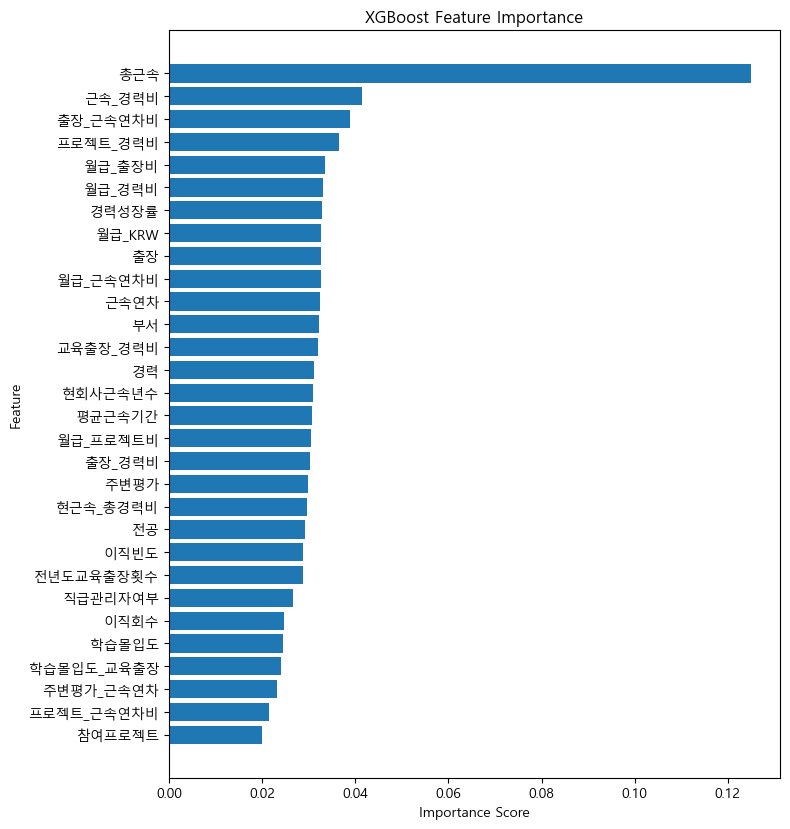

[저장완료] XGBoost Feature Importance Plot → C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_feature_engineered_plus_xgb_importance.png

=== Top 20 Features ===
     feature  importance
15       총근속    0.124966
21    근속_경력비    0.041537
26  출장_근속연차비    0.038957
23  프로젝트_경력비    0.036406
20    월급_출장비    0.033462
12    월급_경력비    0.032967
16     경력성장률    0.032951
10    월급_KRW    0.032681
1         출장    0.032665
19  월급_근속연차비    0.032583
4       근속연차    0.032434
2         부서    0.032221
27  교육출장_경력비    0.032061
7         경력    0.031223
9    현회사근속년수    0.030875
22    평균근속기간    0.030615
13  월급_프로젝트비    0.030578
25    출장_경력비    0.030218
6       주변평가    0.029762
14  현근속_총경력비    0.029563


In [13]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

# ====== 경로 ======
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\인사평가ver2\인사평가_feature_engineered_plus.csv"
OUT_IMG   = str(Path(INPUT_CSV).with_name(Path(INPUT_CSV).stem + "_xgb_importance.png"))

# ====== 데이터 로드 ======
df = pd.read_csv(INPUT_CSV)

# ====== 타깃 선택 (업무평가2 있으면 그걸, 없으면 업무평가 사용) ======
target_col = "업무평가2" if "업무평가2" in df.columns else "업무평가"
y = df[target_col].copy()
X = df.drop(columns=[target_col])

# 문자 타깃 매핑 (보통=0, 좋다/좋음=1)
if y.dtype == object:
    y = y.astype(str).str.strip().map({"보통": 0, "좋다": 1, "좋음": 1, "0": 0, "1": 1}).astype(int)

# ====== 범주형 / 수치형 구분 ======
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# ====== 전처리 파이프라인 ======
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
preprocessor = ColumnTransformer([
    ("cat", cat_pipe, cat_cols),
    ("num", num_pipe, num_cols)
], verbose_feature_names_out=False)

# ====== 데이터 분할 ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ====== 모델 정의 및 학습 ======
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1
)
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb)
])
pipe.fit(X_train, y_train)

# ====== 피처 중요도 DataFrame ======
xgb_model = pipe.named_steps["model"]

# ColumnTransformer 출력 특성 이름(=cat -> num 순서)
feature_names = pipe.named_steps["preprocessor"].get_feature_names_out().tolist()

importances = xgb_model.feature_importances_
feat_importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
      .sort_values(by="importance", ascending=True)  # 그래프 보기 좋게 오름차순
)

# ====== 시각화 & 저장 ======
plt.figure(figsize=(8, max(6, len(feat_importance_df) * 0.28)))
plt.barh(feat_importance_df["feature"], feat_importance_df["importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.savefig(OUT_IMG, dpi=150)
plt.show()

print(f"[저장완료] XGBoost Feature Importance Plot → {OUT_IMG}")

# ====== 상위 20개 출력 ======
print("\n=== Top 20 Features ===")
print(feat_importance_df.sort_values(by="importance", ascending=False).head(20))
